In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
DATA_PATH = Path("../data/raw/mvtec_ad")

category = "bottle"
category_path = DATA_PATH / category

train_good_path = category_path / "train" / "good"
test_path = category_path / "test"
ground_truth_path = category_path / "ground_truth"

In [3]:
normal_paths = sorted(train_good_path.glob("*.png"))

len(normal_paths), normal_paths[:3]

(209,
 [PosixPath('../data/raw/mvtec_ad/bottle/train/good/000.png'),
  PosixPath('../data/raw/mvtec_ad/bottle/train/good/001.png'),
  PosixPath('../data/raw/mvtec_ad/bottle/train/good/002.png')])

In [4]:
def load_grayscale(path):
    image = Image.open(path).convert("L")
    return np.array(image).astype(np.float32)

In [5]:
normal_images = []

for path in normal_paths:
    image = load_grayscale(path)
    normal_images.append(image)

normal_stack = np.stack(normal_images)
average_normal = normal_stack.mean(axis=0)

normal_stack.shape, average_normal.shape

((209, 900, 900), (900, 900))

## Average Normal Image
We build a simple reference image by averaging all normal training images.
This gives us an approximate good bottle. Later, we compare test images against this reference to get a simple anomaly map.

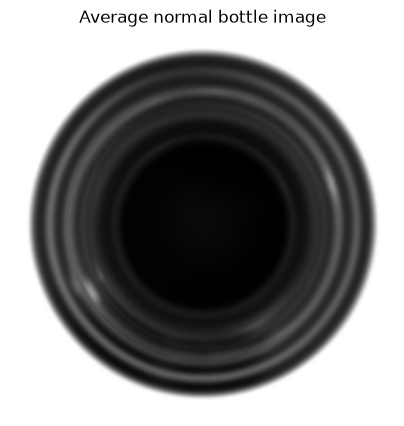

In [6]:
plt.figure(figsize=(5,5))
plt.imshow(average_normal, cmap = "gray")
plt.title("Average normal bottle image")
plt.axis("off")
plt.show()

In [7]:
defect_type = "broken_small"
image_id = "000"

test_image_path = test_path / defect_type / f"{image_id}.png"
mask_path = ground_truth_path / defect_type / f"{image_id}_mask.png"

test_image = load_grayscale(test_image_path)
ground_truth_mask = np.array(Image.open(mask_path)) > 0

test_image.shape, ground_truth_mask.shape

((900, 900), (900, 900))

In [8]:
difference = np.abs(test_image-average_normal)
difference.min(), difference.max(),difference.mean()


(np.float32(0.0), np.float32(201.17224), np.float32(5.261531))

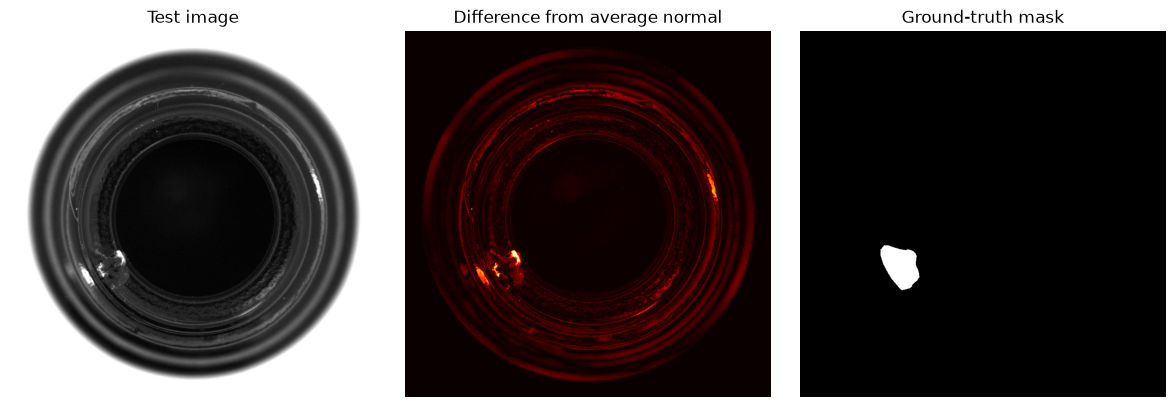

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(test_image, cmap="gray")
axes[0].set_title("Test image")
axes[0].axis("off")

axes[1].imshow(difference, cmap="hot")
axes[1].set_title("Difference from average normal")
axes[1].axis("off")

axes[2].imshow(ground_truth_mask, cmap="gray")
axes[2].set_title("Ground-truth mask")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## Thresholding the difference map
The difference image is an anomaly map: higher values mean stronger deviation from the average normal image.
To create a predicted defect mask, we choose a threshold. Pixels aove the threshold are predicted as anomalous.

In [10]:
threshold = np.percentile(difference, 99.5)
predicted_mask = difference > threshold 
threshold, predicted_mask.sum()

(np.float32(42.655502), np.int64(4049))

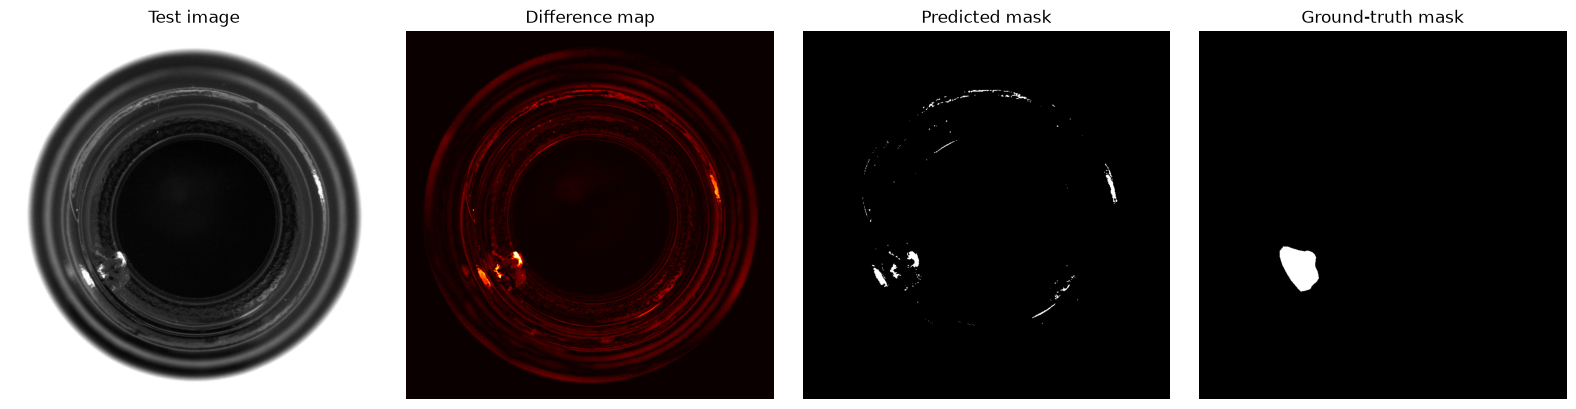

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(test_image, cmap="gray")
axes[0].set_title("Test image")
axes[0].axis("off")

axes[1].imshow(difference, cmap="hot")
axes[1].set_title("Difference map")
axes[1].axis("off")

axes[2].imshow(predicted_mask, cmap="gray")
axes[2].set_title("Predicted mask")
axes[2].axis("off")

axes[3].imshow(ground_truth_mask, cmap="gray")
axes[3].set_title("Ground-truth mask")
axes[3].axis("off")

plt.tight_layout()
plt.show()

In [14]:
def compute_mask_metrics(predicted_mask, ground_truth_mask):
    true_positive = np.logical_and(predicted_mask, ground_truth_mask).sum()
    false_positive = np.logical_and(predicted_mask, ~ground_truth_mask).sum()
    false_negative = np.logical_and(~predicted_mask, ground_truth_mask).sum()

    precision = true_positive / (true_positive + false_positive) if (true_positive + false_positive) > 0 else 0
    recall = true_positive / (true_positive + false_negative) if (true_positive + false_negative) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    iou = true_positive / (true_positive + false_positive + false_negative) if (true_positive + false_positive + false_negative) > 0 else 0

    return precision, recall, f1, iou

In [15]:
threshold_results = []

for percentile in [98, 99, 99.5, 99.7, 99.9]:
    threshold = np.percentile(difference, percentile)
    predicted_mask = difference > threshold
    
    precision, recall, f1, iou = compute_mask_metrics(predicted_mask, ground_truth_mask)
    
    threshold_results.append({
        "percentile": percentile,
        "threshold": threshold,
        "predicted_pixels": predicted_mask.sum(),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "iou": iou,
    })

threshold_results = pd.DataFrame(threshold_results)
threshold_results

,percentile,threshold,predicted_pixels,precision,recall,f1,iou
0,98.0,28.014359,16199,0.134514,0.304075,0.186518,0.102851
1,99.0,33.100479,8097,0.195381,0.220765,0.207299,0.115635
2,99.5,42.655502,4049,0.271672,0.153503,0.196166,0.108749
3,99.7,56.378006,2430,0.337860,0.114569,0.171113,0.093561
4,99.9,108.712967,810,0.541975,0.061262,0.110080,0.058246


## Threshold Sensitivity Observation
The threshold strongly changes the behaviour of the predicted mask.
Lower thresholds detect more of the real defect but introduce many false positives. Higher thresholds reduce false positives but miss most of the defect.

In [16]:
best_row = threshold_results.sort_values("f1", ascending=False).iloc[0]

best_percentile = best_row["percentile"]
best_threshold = best_row["threshold"]

best_predicted_mask = difference > best_threshold

best_percentile, best_threshold

(np.float64(99.0), np.float64(33.10047912597656))

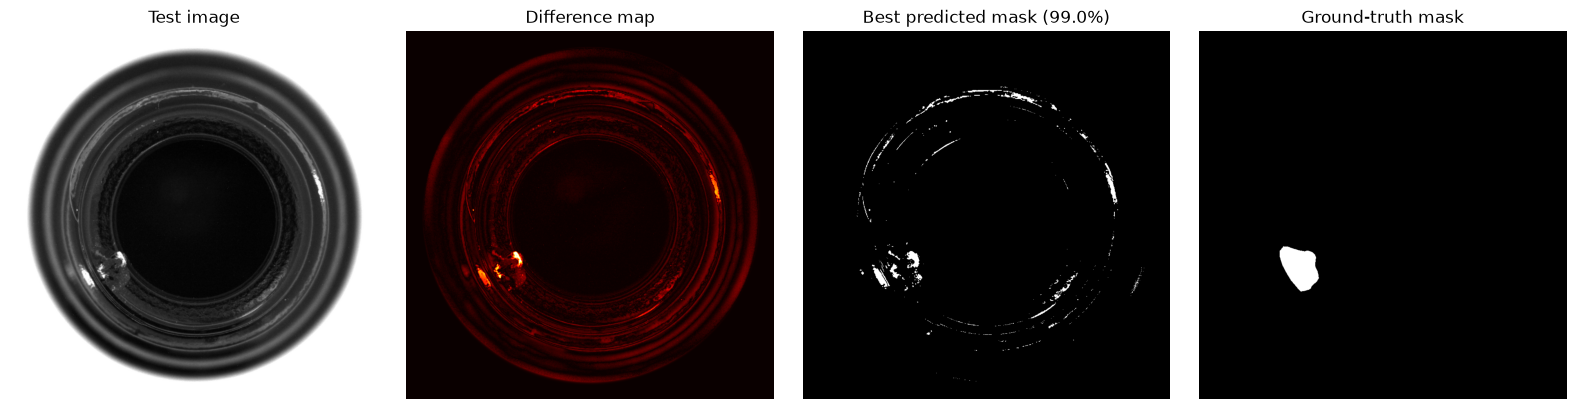

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(test_image, cmap="gray")
axes[0].set_title("Test image")
axes[0].axis("off")

axes[1].imshow(difference, cmap="hot")
axes[1].set_title("Difference map")
axes[1].axis("off")

axes[2].imshow(best_predicted_mask, cmap="gray")
axes[2].set_title(f"Best predicted mask ({best_percentile:.1f}%)")
axes[2].axis("off")

axes[3].imshow(ground_truth_mask, cmap="gray")
axes[3].set_title("Ground-truth mask")
axes[3].axis("off")

plt.tight_layout()
plt.show()

## Connected Components

The predicted mask contains many separate white regions. Some may correspond to the real defect, while others are small false positives from edges or reflections.

Connected component analysis labels each separate white region so we can inspect and filter them.

In [18]:
from skimage.measure import label, regionprops
labeled_mask = label(best_predicted_mask)
regions = regionprops(labeled_mask)

len(regions)

487

In [19]:
region_rows = []

for region in regions:
    region_rows.append({
        "label": region.label,
        "area": region.area,
        "bbox": region.bbox,
    })

regions_df = pd.DataFrame(region_rows).sort_values("area", ascending=False)
regions_df.head(10)

,label,area,bbox
208,209,712.0,"(538, 255, 579, 286)"
244,245,662.0,"(578, 172, 626, 208)"
151,152,659.0,"(350, 742, 424, 770)"
13,14,562.0,"(150, 509, 186, 585)"
232,233,370.0,"(569, 213, 605, 241)"
6,7,286.0,"(144, 404, 150, 488)"
355,356,238.0,"(666, 559, 703, 620)"
23,24,234.0,"(158, 346, 176, 408)"
34,35,218.0,"(172, 276, 210, 324)"
298,299,192.0,"(617, 620, 642, 655)"


In [20]:
min_area = 100

filtered_mask = np.zeros_like(best_predicted_mask)

for region in regions:
    if region.area >= min_area:
        filtered_mask[labeled_mask == region.label] = True

filtered_mask.sum()

np.int64(5353)

In [22]:
precision, recall, f1, iou = compute_mask_metrics(filtered_mask, ground_truth_mask)

precision, recall, f1, iou

(np.float64(0.22772277227722773),
 np.float64(0.17010884733463577),
 np.float64(0.1947439891365125),
 np.float64(0.10787610619469026))

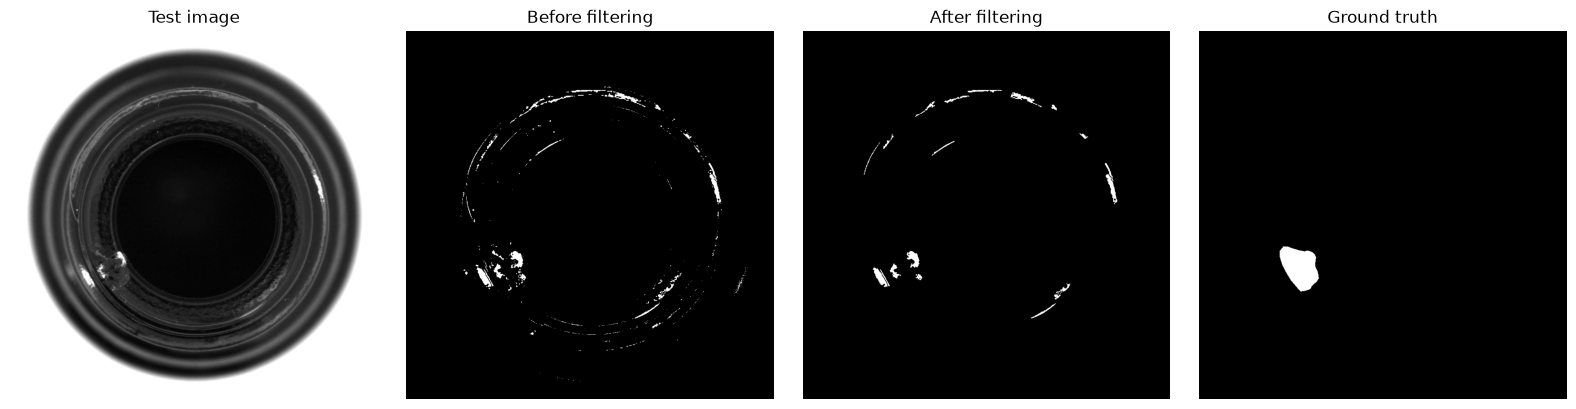

In [21]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(test_image, cmap="gray")
axes[0].set_title("Test image")
axes[0].axis("off")

axes[1].imshow(best_predicted_mask, cmap="gray")
axes[1].set_title("Before filtering")
axes[1].axis("off")

axes[2].imshow(filtered_mask, cmap="gray")
axes[2].set_title("After filtering")
axes[2].axis("off")

axes[3].imshow(ground_truth_mask, cmap="gray")
axes[3].set_title("Ground truth")
axes[3].axis("off")

plt.tight_layout()
plt.show()

## Observation
Connected component filtering removes some small noisy regions from the predicted mask.
However, many false positives remain because bottle edges and reflections differ strongly from the average normal image. This confirms that average image differencing is a weak but useful baseline.